In [2]:
import pandas as pd
import numpy as np 
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [3]:
INPUT_PATH = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"
OUTPUT_PATH = '../data/openfoodfacts_regression_clean.csv'
 
# Colonnes pour les features et la cible numérique
nutriscore_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g'
]
 
# Changement : on vise le SCORE (numérique)
target = 'nutriscore_score'
identity_cols = ['code', 'product_name', 'nutriscore_grade'] # On garde le grade juste pour info
 
cols = nutriscore_cols + [target] + identity_cols
def process_data(file_path, cols, chunk_size=20000):
    reader = pd.read_csv(
        file_path, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=chunk_size,
        low_memory=False, usecols=cols
    )
 
    clean_chunks = []
    print("Lecture des blocs...")
    
    for i, chunk in enumerate(reader):
 
        temp_chunk = chunk.copy()
 
        # 1. Nettoyage de la Cible (Target)
        # On supprime les lignes où le score numérique manque
        temp_chunk = temp_chunk.dropna(subset=[target])
        cols_to_convert = nutriscore_cols + [target]
 
        # 2. Conversion numérique des nutriments
        for col in cols_to_convert:
            temp_chunk[col] = pd.to_numeric(temp_chunk[col], errors='coerce')
 
        # Filtre de réalisme pour le score (Officiel : -15 à +40)
        temp_chunk = temp_chunk[(temp_chunk[target] >= -15) & (temp_chunk[target] <= 40)]            
 
        # Remplissage des nutriments manquants par 0 (Imputation)
        temp_chunk[nutriscore_cols] = temp_chunk[nutriscore_cols].fillna(0)
        
        # 3. Filtres Outliers (0-100g et Energie)
        for col in nutriscore_cols:
            if col != 'energy_100g':
                temp_chunk = temp_chunk[(temp_chunk[col] >= 0) & (temp_chunk[col] <= 100)]
        
        temp_chunk = temp_chunk[(temp_chunk['energy_100g'] >= 0) & (temp_chunk['energy_100g'] < 4000)]
 
        # 4. Gestion de l'identité
        temp_chunk['product_name'] = temp_chunk['product_name'].fillna('Unknown Product')
        temp_chunk = temp_chunk.drop_duplicates(subset=['code'])
 
         # 5. Stockage du bloc propre
        if not temp_chunk.empty:
            clean_chunks.append(temp_chunk)
        
        if i % 10 == 0:
            print(f"Bloc {i} chargé...")
    
    print("Fusion de tous les blocs...")
    df_final = pd.concat(clean_chunks, ignore_index=True)
    
    return df_final
 
 
# Lancement
df_raw = process_data(INPUT_PATH, cols)

Lecture des blocs...
Bloc 0 chargé...
Bloc 10 chargé...
Bloc 20 chargé...
Bloc 30 chargé...
Bloc 40 chargé...
Bloc 50 chargé...
Bloc 60 chargé...
Bloc 70 chargé...
Bloc 80 chargé...
Bloc 90 chargé...
Bloc 100 chargé...
Bloc 110 chargé...
Bloc 120 chargé...
Bloc 130 chargé...
Bloc 140 chargé...
Bloc 150 chargé...
Bloc 160 chargé...
Bloc 170 chargé...
Bloc 180 chargé...
Bloc 190 chargé...
Bloc 200 chargé...
Bloc 210 chargé...
Bloc 220 chargé...
Fusion de tous les blocs...


In [3]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df_raw.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

print(f"Fichier sauvegardé ici : {OUTPUT_PATH}")

Fichier sauvegardé ici : ../data/openfoodfacts_regression_clean.csv


In [4]:
# Copie de travail
df = df_raw.copy()

print("Shape initiale :", df.shape)
print("\nTypes :")
display(df.dtypes)

print("\nValeurs manquantes :")
display(df.isna().sum().sort_values(ascending=False))

Shape initiale : (1351783, 12)

Types :


code                   object
product_name           object
nutriscore_score      float64
nutriscore_grade       object
energy_100g           float64
fat_100g              float64
saturated-fat_100g    float64
carbohydrates_100g    float64
sugars_100g           float64
fiber_100g            float64
proteins_100g         float64
salt_100g             float64
dtype: object


Valeurs manquantes :


code                  0
product_name          0
nutriscore_score      0
nutriscore_grade      0
energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
dtype: int64

In [5]:
# Colonnes utiles
feature_cols = nutriscore_cols.copy()
id_cols = ['code', 'product_name', 'nutriscore_grade']
target_col = target

# Suppression des doublons globaux sur le code
df = df.drop_duplicates(subset=['code']).copy()

# On garde uniquement les lignes avec une cible connue
df = df[df[target_col].notna()].copy()

# Conversion de sécurité
for col in feature_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputation simple sur les colonnes nutritionnelles
df[feature_cols] = df[feature_cols].fillna(0)

# Suppression des lignes aberrantes sur la cible
df = df[df[target_col].between(-15, 40)].copy()

print("Shape après nettoyage :", df.shape)
df.head()

Shape après nettoyage : (1351783, 12)


,code,product_name,nutriscore_score,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,7,granola Bio le Chocolaté,4.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8,Unknown Product,6.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9,xytitol pastilles,-11.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13,Powdered peanut butter,3.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,15,Madeleines ChocoLait,20.0,e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Nombre de nutriments non nuls par ligne
df['non_zero_features'] = (df[feature_cols] > 0).sum(axis=1)

# Option: on enlève les lignes sans aucune vraie info nutritionnelle
df = df[df['non_zero_features'] > 0].copy()

print("Shape après retrait des lignes sans info nutritionnelle :", df.shape)
df[['non_zero_features'] + feature_cols].head()

Shape après retrait des lignes sans info nutritionnelle : (277964, 13)


,non_zero_features,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g
86,7,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649
97,3,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000
98,7,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900
116,8,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700
117,8,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760


In [7]:
# Variables dérivées
df['total_macro_100g'] = (
    df['fat_100g'] +
    df['carbohydrates_100g'] +
    df['proteins_100g'] +
    df['fiber_100g']
)

df['sugar_to_carb_ratio'] = np.where(
    df['carbohydrates_100g'] > 0,
    df['sugars_100g'] / df['carbohydrates_100g'],
    0
)

df['satfat_to_fat_ratio'] = np.where(
    df['fat_100g'] > 0,
    df['saturated-fat_100g'] / df['fat_100g'],
    0
)

df['protein_to_energy_ratio'] = np.where(
    df['energy_100g'] > 0,
    df['proteins_100g'] / df['energy_100g'],
    0
)

df['fiber_to_carb_ratio'] = np.where(
    df['carbohydrates_100g'] > 0,
    df['fiber_100g'] / df['carbohydrates_100g'],
    0
)

derived_cols = [
    'non_zero_features',
    'total_macro_100g',
    'sugar_to_carb_ratio',
    'satfat_to_fat_ratio',
    'protein_to_energy_ratio',
    'fiber_to_carb_ratio'
]

all_features = feature_cols + derived_cols

print("Nombre total de features :", len(all_features))
df[all_features + [target_col]].head()

Nombre total de features : 14


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
86,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.0
97,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000,3,36.700001,0.000000,0.346049,0.000000,0.000000,14.0
98,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.0
116,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700,8,6.400000,0.377778,0.500000,0.006387,0.177778,3.0
117,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760,8,8.100000,0.418182,0.500000,0.004895,0.200000,3.0


In [8]:
# Dataset final pour la régression
training_df = df[all_features + [target_col]].dropna().copy()

print("Shape training_df :", training_df.shape)
training_df.head()

Shape training_df : (277964, 15)


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
86,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.0
97,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000,3,36.700001,0.000000,0.346049,0.000000,0.000000,14.0
98,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.0
116,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700,8,6.400000,0.377778,0.500000,0.006387,0.177778,3.0
117,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760,8,8.100000,0.418182,0.500000,0.004895,0.200000,3.0


In [9]:
X = training_df[all_features].copy()
y = training_df[target_col].copy()

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (277964, 14)
Shape y : (277964,)


In [10]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []
pipelines = []

for k in range(3, len(all_features) + 1):
    pipe = Pipeline([
        ('selector', SelectKBest(score_func=mutual_info_regression, k=k)),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append({
        'k': k,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })
    pipelines.append({
        'k': k,
        'pipeline': pipe
    })

results_df = pd.DataFrame(results).sort_values(by='RMSE')
display(results_df.head(10))

,k,RMSE,MAE,R2
11,14,1.829455,0.841336,0.965013
10,13,1.831043,0.841355,0.964952
9,12,1.847247,0.861735,0.964329
8,11,1.980852,1.013100,0.958983
6,9,1.982495,1.016806,0.958914
7,10,1.987182,1.020348,0.958720
5,8,2.024050,1.055144,0.957174
4,7,3.879709,2.226722,0.842651
3,6,3.884056,2.232454,0.842298
2,5,4.460437,2.681806,0.792021


<Axes: title={'center': 'RMSE selon le nombre de features'}, xlabel='k'>

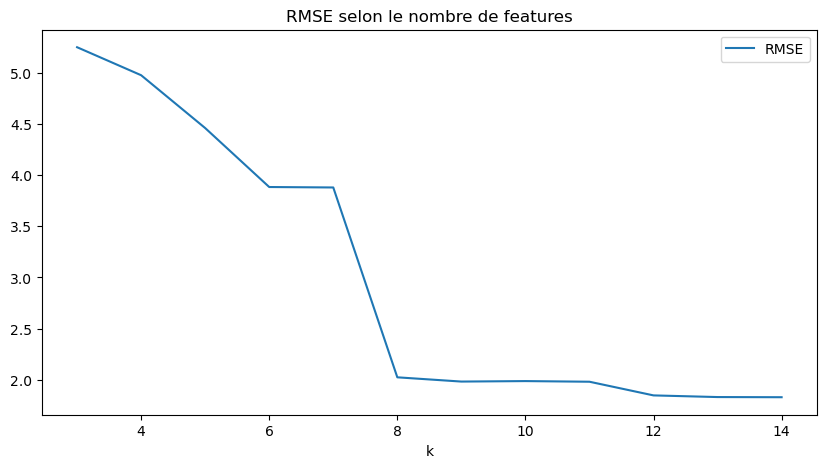

In [11]:
results_df.sort_values('k').plot(x='k', y='RMSE', figsize=(10, 5), title='RMSE selon le nombre de features')

In [12]:
best_k = results_df.iloc[0]['k']
best_pipeline = next(p['pipeline'] for p in pipelines if p['k'] == best_k)

mask = best_pipeline.named_steps['selector'].get_support()
selected_features = X.columns[mask].tolist()

print("Best k :", int(best_k))
print("Features retenues :")
selected_features

Best k : 14
Features retenues :


['energy_100g',
 'fat_100g',
 'saturated-fat_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'carbohydrates_100g',
 'salt_100g',
 'non_zero_features',
 'total_macro_100g',
 'sugar_to_carb_ratio',
 'satfat_to_fat_ratio',
 'protein_to_energy_ratio',
 'fiber_to_carb_ratio']

In [13]:
final_training_df = training_df[selected_features + [target_col]].copy()

print("Shape final_training_df :", final_training_df.shape)
final_training_df.head()

Shape final_training_df : (277964, 15)


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
86,1928.500000,28.000000,13.8,18.0,0.0,6.000000,46.5,0.649,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.0
97,1357.900028,36.700001,12.7,0.0,0.0,0.000000,0.0,0.000,3,36.700001,0.000000,0.346049,0.000000,0.000000,14.0
98,1771.899957,35.299999,12.2,4.1,0.0,22.299999,5.1,3.900,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.0
116,109.600000,0.400000,0.2,1.7,0.8,0.700000,4.5,0.700,8,6.400000,0.377778,0.500000,0.006387,0.177778,3.0
117,143.000000,0.800000,0.4,2.3,1.1,0.700000,5.5,0.760,8,8.100000,0.418182,0.500000,0.004895,0.200000,3.0


In [14]:
FINAL_OUTPUT_PATH = '../data/openfoodfacts_regression_training_ready.csv'
os.makedirs(os.path.dirname(FINAL_OUTPUT_PATH), exist_ok=True)

final_training_df.to_csv(FINAL_OUTPUT_PATH, index=False, encoding='utf-8')
print(f"Dataset prêt sauvegardé ici : {FINAL_OUTPUT_PATH}")

Dataset prêt sauvegardé ici : ../data/openfoodfacts_regression_training_ready.csv


# À partir d'ici on test le XGBoost

In [15]:
X_final = final_training_df[selected_features]
y_final = final_training_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

print("MAE  :", mean_absolute_error(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2   :", r2_score(y_test, y_pred))

MAE  : 0.839008017463485
RMSE : 1.8265066729993988
R2   : 0.965125552898595


In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGB - MAE  :", mean_absolute_error(y_test, xgb_pred))
print("XGB - RMSE :", mean_squared_error(y_test, xgb_pred) ** 0.5)
print("XGB - R2   :", r2_score(y_test, xgb_pred))

XGB - MAE  : 1.0636989922913753
XGB - RMSE : 1.8918225295682543
XGB - R2   : 0.9625867366525728


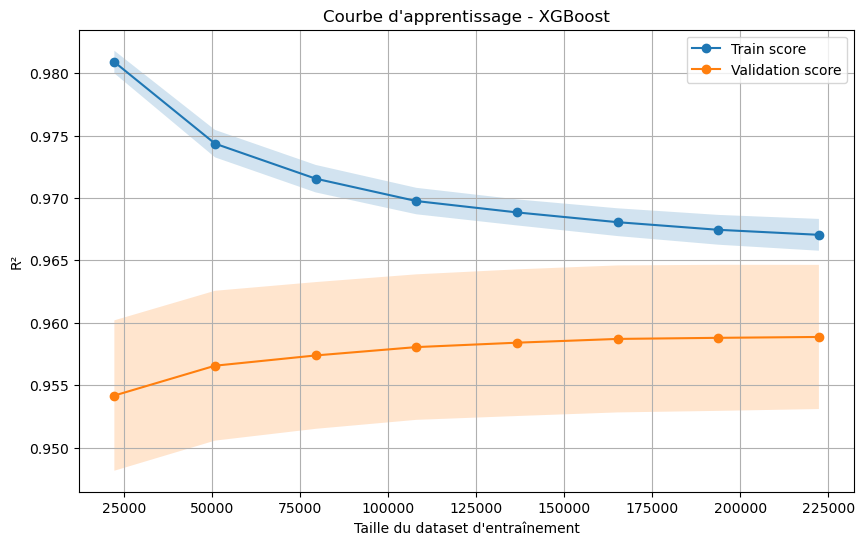

In [25]:
from sklearn.model_selection import learning_curve
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

# Modèle (reprend les mêmes paramètres que ton XGBoost)
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Calcul des learning curves
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_final,
    y_final,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, label="Train score", marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, test_mean, label="Validation score", marker='o')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.title("Courbe d'apprentissage - XGBoost")
plt.xlabel("Taille du dataset d'entraînement")
plt.ylabel("R²")
plt.legend()
plt.grid()

plt.show()

## Test pour vérifier le data leakage et tout

In [17]:
print(set(X_train.index) & set(X_test.index))

set()


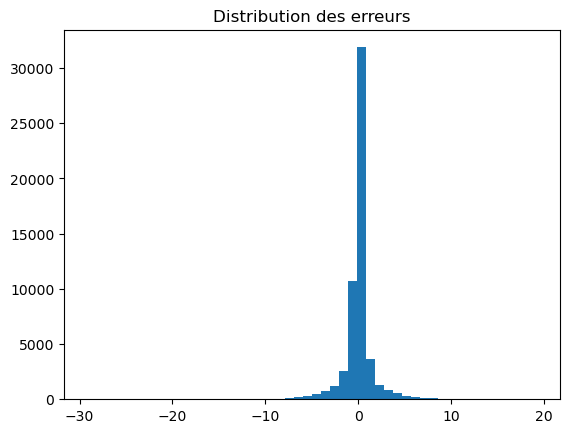

In [18]:
import matplotlib.pyplot as plt

errors = y_test - y_pred

plt.hist(errors, bins=50)
plt.title("Distribution des erreurs")
plt.show()

In [19]:
# Conversion du score prédit en Nutri-Score (A, B, C, D, E)

def score_to_grade(score):
    """
    Conversion standard du Nutri-Score pour les aliments généraux :
    A : score <= -1
    B : 0 à 2
    C : 3 à 10
    D : 11 à 18
    E : >= 19
    """
    if score <= -1:
        return "A"
    elif score <= 2:
        return "B"
    elif score <= 10:
        return "C"
    elif score <= 18:
        return "D"
    else:
        return "E"

# Prédictions du modèle déjà entraîné
y_pred_score = xgb_model.predict(X_test)

# Conversion en lettres
y_pred_grade = pd.Series(y_pred_score).apply(score_to_grade)
y_true_grade = pd.Series(y_test).apply(score_to_grade).reset_index(drop=True)

# Tableau de sortie
results_grades = pd.DataFrame({
    "true_score": y_test.reset_index(drop=True),
    "pred_score": y_pred_score,
    "true_grade": y_true_grade,
    "pred_grade": y_pred_grade
})

display(results_grades.head(20))

,true_score,pred_score,true_grade,pred_grade
0,24.0,25.157066,E,E
1,15.0,14.824952,D,D
2,-1.0,-0.292385,A,B
3,31.0,30.912680,E,E
4,8.0,7.548779,C,C
5,1.0,0.286839,B,B
6,23.0,22.605743,E,E
7,7.0,5.229846,C,C
8,-3.0,-1.497015,A,A
9,11.0,11.305688,D,D


## Prédiction sur le dataset final

In [20]:
# Prédire le Nutri-Score lettre sur toutes les lignes du dataset final
all_pred_scores = xgb_model.predict(X_final)
all_pred_grades = pd.Series(all_pred_scores).apply(score_to_grade)

predictions_df = X_final.copy()
predictions_df["predicted_score"] = all_pred_scores
predictions_df["predicted_nutriscore"] = all_pred_grades

display(predictions_df.head(20))

,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,predicted_score,predicted_nutriscore
86,1928.500000,28.000000,13.80,18.000000,0.0,6.000000,46.500000,0.649000,7,80.500000,0.387097,0.492857,0.003111,0.000000,23.339678,C
97,1357.900028,36.700001,12.70,0.000000,0.0,0.000000,0.000000,0.000000,3,36.700001,0.000000,0.346049,0.000000,0.000000,11.224319,D
98,1771.899957,35.299999,12.20,4.100000,0.0,22.299999,5.100000,3.900000,7,62.699998,0.803922,0.345609,0.012585,0.000000,35.741341,E
116,109.600000,0.400000,0.20,1.700000,0.8,0.700000,4.500000,0.700000,8,6.400000,0.377778,0.500000,0.006387,0.177778,1.855713,B
117,143.000000,0.800000,0.40,2.300000,1.1,0.700000,5.500000,0.760000,8,8.100000,0.418182,0.500000,0.004895,0.200000,1.854228,C
118,150.000000,1.200000,0.40,1.400000,1.5,0.900000,4.600000,0.700000,8,8.200000,0.304348,0.333333,0.006000,0.326087,1.735185,C
119,161.000000,1.500000,1.00,2.000000,0.8,0.900000,4.900000,0.740000,8,8.100000,0.408163,0.666667,0.005590,0.163265,2.911459,B
121,147.500000,1.700000,0.30,1.400000,0.8,0.900000,3.700000,0.670000,8,7.100000,0.378378,0.176471,0.006102,0.216216,2.568893,C
122,146.500000,1.400000,0.90,1.400000,1.0,0.900000,4.200000,0.650000,8,7.500000,0.333333,0.642857,0.006143,0.238095,2.980878,D
125,118.300000,0.500000,0.30,2.400000,1.0,0.700000,4.700000,0.670000,8,6.900000,0.510638,0.600000,0.005917,0.212766,2.003346,C


## Analyse des performances du modèle

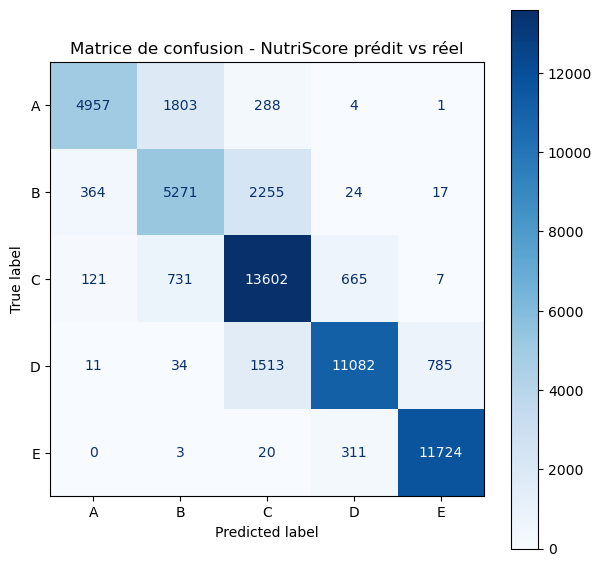

Accuracy NutriScore (A-E) : 0.8389

Classification report :
              precision    recall  f1-score   support

           A       0.91      0.70      0.79      7053
           B       0.67      0.66      0.67      7931
           C       0.77      0.90      0.83     15126
           D       0.92      0.83      0.87     13425
           E       0.94      0.97      0.95     12058

    accuracy                           0.84     55593
   macro avg       0.84      0.81      0.82     55593
weighted avg       0.84      0.84      0.84     55593



In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Fonction de conversion score -> grade
def score_to_grade(score):
    if score <= -1:
        return "A"
    elif score <= 2:
        return "B"
    elif score <= 10:
        return "C"
    elif score <= 18:
        return "D"
    else:
        return "E"

# Prédictions numériques -> lettres
y_pred_score = xgb_model.predict(X_test)

y_true_grade = pd.Series(y_test).apply(score_to_grade).reset_index(drop=True)
y_pred_grade = pd.Series(y_pred_score).apply(score_to_grade)

labels = ["A", "B", "C", "D", "E"]

# Matrice de confusion
cm = confusion_matrix(y_true_grade, y_pred_grade, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matrice de confusion - NutriScore prédit vs réel")
plt.show()

# Métriques de classification
acc = accuracy_score(y_true_grade, y_pred_grade)
print(f"Accuracy NutriScore (A-E) : {acc:.4f}\n")

print("Classification report :")
print(classification_report(y_true_grade, y_pred_grade, labels=labels))

In [23]:
# Contrôle de surapprentissage 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prédictions train / test
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Scores régression
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

evaluation_df = pd.DataFrame({
    "Jeu": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

display(evaluation_df)

print("Écart Train/Test :")
print(f"Différence MAE  : {abs(train_mae - test_mae):.4f}")
print(f"Différence RMSE : {abs(train_rmse - test_rmse):.4f}")
print(f"Différence R2   : {abs(train_r2 - test_r2):.4f}")

# Diagnostic simple
if train_r2 > test_r2 + 0.05:
    print("\n⚠️ Alerte possible de surapprentissage : le score Train est sensiblement meilleur que le score Test.")
else:
    print("\n✅ Pas de signe fort de surapprentissage : les performances Train et Test sont proches.")

,Jeu,MAE,RMSE,R2
0,Train,1.014186,1.775391,0.966743
1,Test,1.063699,1.891823,0.962587


Écart Train/Test :
Différence MAE  : 0.0495
Différence RMSE : 0.1164
Différence R2   : 0.0042

✅ Pas de signe fort de surapprentissage : les performances Train et Test sont proches.


In [24]:
# Cross validation 
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor
import numpy as np

cv_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(cv_model, X_final, y_final, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(cv_model, X_final, y_final, cv=kf, scoring='neg_root_mean_squared_error')

print("Validation croisée 5-fold")
print(f"R2 moyen   : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")
print(f"RMSE moyen : {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}")

Validation croisée 5-fold
R2 moyen   : 0.9618 +/- 0.0011
RMSE moyen : 1.9039 +/- 0.0261
